# J=1 splittings along the Ramsey RF DC trajectory

Companion to `demo_ramsey_rf.ipynb`. Same geometry, same DC field profile (2 → 30 → 2 kV/cm), same target bare state.

Plots the energy difference (in kHz) between the populated dressed eigenstate and the other 11 J=1 dressed eigenstates as a function of |E_dc| and as a function of position `z` along the trajectory. Eigenstate ordering is maintained across the sweep with the Hungarian algorithm (`scipy.optimize.linear_sum_assignment`) on the adjacent-step overlap matrix — same pattern used in `examples/effective hamiltonian/energy_levels_J1.ipynb`.

The ~120 kHz populated↔m1=+1/2 sibling splitting (visible in Section 9 — set by the Tl spin-rotation `c1·I_Tl·J` interaction) is the resonance the demo's **magnetic** RF carrier (`OMEGA_RF = 2π·120 kHz`) is tuned to. The transition itself is an NMR-style nuclear spin flip — see `demo_ramsey_rf_coupling.ipynb` for the matrix element of the magnetic-dipole coupling `HZx` between these two states.

**Sweep strategy.** The DC E-field direction is fixed `(0, 0, 1)`, so the Stark eigenvalues at any `z` depend only on `|E_dc(z)|`. We compute the Stark map *once* on a uniform `|E|` grid from 2 → 30 kV/cm with Hungarian tracking, then map back to the trajectory `z` by interpolating at `|E_dc(z)|` on each leg. Sampling in |E| (rather than in z) gives near-constant per-step Stark shifts and makes Hungarian assignment robust through the steep DC ramps where `dE/dz` peaks at ~280 (V/cm)/mm.

Jmax=6 (basis size 196) to fully capture J-mixing at 30 kV/cm. No RF, no time stepping — only a static Stark map traced along the trajectory.

In [1]:
from __future__ import annotations

import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

HERE = os.path.dirname(os.path.abspath("demo_ramsey_rf_splittings.ipynb"))
if HERE not in sys.path:
    sys.path.insert(0, HERE)

from centrex_tlf.hamiltonian import generate_uncoupled_hamiltonian_X
from centrex_tlf.states import ElectronicState, UncoupledBasisState

from ramsey_rf import (
    AnalyticDCField,
    adiabatic_dressed_initial_states,
    build_H_func,
    build_basis,
    dressed_initial_states,
)
from ramsey_rf.states import UncoupledSelector

%matplotlib inline

## 1. Geometry (matches `demo_ramsey_rf.ipynb`)

Only the DC field is needed here â€” the splittings are static.

In [2]:
DC_HALF_WIDTH = 1.50  # m
DC_RAMP_LENGTH = 0.05  # m
E_LOW, E_HIGH = 2e3, 30e3  # V/cm
Z_START, Z_FINAL = -2.0, +2.0  # m

# Jmax=6 (basis 196): full J-mixing at 30 kV/cm. No time stepping here â€” just static eigh.
JMAX = 6

# Tiny B bias (mirrors examples/effective hamiltonian/energy_levels_J1.ipynb) to lift exact
# degeneracies and make Hungarian assignment well-defined.
B_BIAS = np.array([0.0, 0.0, 1e-5])

dc = AnalyticDCField.symmetric_plateau(
    E_low=E_LOW,
    E_high=E_HIGH,
    half_width=DC_HALF_WIDTH,
    ramp_length=DC_RAMP_LENGTH,
    direction=(0, 0, 1),
)

## 2. Basis and H(E, B) callable

In [3]:
QN = build_basis(Jmax=JMAX)
H_func = build_H_func(QN)
H_uncoupled = generate_uncoupled_hamiltonian_X(QN)  # for batched eigh in section 4
print(f"Basis size: {len(QN)} (Jmax={JMAX})")

Basis size: 196 (Jmax=6)


## 3. Identify the populated branch and the J=1 set at the entrance field (2 kV/cm)

The populated state is the adiabatic ancestor at 2 kV/cm of the bare `|J=1, mJ=-1, m1=-1/2, m2=-1/2âŸ©` at 30 kV/cm â€” same target the demo notebook uses.

The J=1 set is the 12 dressed eigenstates of `H(E_low, B_bias)` matched to the 12 bare J=1 sublevels via `dressed_initial_states`.

The columns of the |E|-sweep result will be indexed by their identity at `|E| = E_LOW` (the start of the sweep), so these indices directly select the J=1 manifold and the populated branch.

In [4]:
E_low_vec = np.array([0.0, 0.0, E_LOW])
E_high_vec = np.array([0.0, 0.0, E_HIGH])

# Populated state (same target as the demo notebook).
target = UncoupledBasisState(
    J=1,
    mJ=-1,
    I1=0.5,
    m1=-0.5,
    I2=0.5,
    m2=-0.5,
    Omega=0,
    P=-1,
    electronic_state=ElectronicState.X,
)
_Psi0_adiab, init_idx, overlap_at_high = adiabatic_dressed_initial_states(
    H_func,
    E_init=E_low_vec,
    E_target=E_high_vec,
    QN=QN,
    targets=[target],
    n_steps=80,
    B=B_BIAS,
)
populated_idx = int(init_idx[0])
print(f"Populated branch column index at 2 kV/cm: {populated_idx}")
print(f"|<target_bare | dressed at 30 kV/cm>|^2 = {overlap_at_high[0]:.4f}")

# All 12 J=1 dressed eigenstates at 2 kV/cm.
H_low = H_func(E_low_vec, B_BIAS)
_Psi_J1, j1_eig_idx, j1_overlaps = dressed_initial_states(
    H_low, QN, UncoupledSelector(J=1, electronic=ElectronicState.X)
)
j1_idx = np.array(j1_eig_idx, dtype=int)
print(f"J=1 dressed eigenstate column indices at 2 kV/cm: {sorted(j1_idx.tolist())}")
print(f"  count = {len(j1_idx)} (expected 12)")
if populated_idx not in j1_idx:
    print(
        f"WARNING: populated column {populated_idx} is NOT in the J=1 set â€” "
        "check target / B_BIAS / Jmax consistency."
    )
else:
    print(f"  populated column {populated_idx} is in the J=1 set âœ“")

Populated branch column index at 2 kV/cm: 11
|<target_bare | dressed at 30 kV/cm>|^2 = 0.5962
J=1 dressed eigenstate column indices at 2 kV/cm: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  count = 12 (expected 12)
  populated column 11 is in the J=1 set âœ“


## 4. Stark sweep on a uniform |E| grid with Hungarian tracking

2001 points uniform in |E| from `E_LOW` to `E_HIGH` â‡’ Î”E = 14 V/cm. With a TlF X-state Stark slope of â‰ˆ 2.65 GHz/(kV/cm) (4.2 D dipole), per-step shift is â‰¤ ~37 MHz â€” well below typical J=1 avoided-crossing gaps, so Hungarian assignment follows continuous adiabatic branches throughout the sweep.

At each `|E|`, diagonalize `H(|E| áº‘, B_bias)` and reorder `(D, V)` to match the previous step by maximizing `|<V_prev | V>|` via `linear_sum_assignment`. The first step seeds with eigenvalue-sorted columns, which matches the indices returned by `dressed_initial_states` and `adiabatic_dressed_initial_states` above (same eigh of `H(E_LOW, B_BIAS)`).

In [5]:
N_E = 2001
E_grid = np.linspace(E_LOW, E_HIGH, N_E)
N_basis = len(QN)

energies_E = np.empty((N_E, N_basis), dtype=np.float64)
V_low_tracked: np.ndarray | None = None  # eigvecs at E_LOW (first step, identity-ordered)

# Precompute the E-independent part of H once (E points along z, B is constant
# B_BIAS), then build & diagonalize H over chunks of E values via a single
# stacked `np.linalg.eigh` per chunk. Mathematically identical to the
# per-point H_func + eigh loop; just removes the Python overhead.
H_const = 2 * np.pi * (
    H_uncoupled.Hff
    + B_BIAS[0] * H_uncoupled.HZx
    + B_BIAS[1] * H_uncoupled.HZy
    + B_BIAS[2] * H_uncoupled.HZz
)
HSz_2pi = 2 * np.pi * H_uncoupled.HSz

CHUNK_SIZE = 256  # ~120 MB per chunk for complex128 196² stacks

t0 = time.perf_counter()
prev_vectors: np.ndarray | None = None
for chunk_start in range(0, N_E, CHUNK_SIZE):
    chunk_end = min(chunk_start + CHUNK_SIZE, N_E)
    E_chunk = E_grid[chunk_start:chunk_end]
    H_chunk = H_const[None, :, :] + E_chunk[:, None, None] * HSz_2pi[None, :, :]
    eigvals_chunk, eigvecs_chunk = np.linalg.eigh(H_chunk)
    for k in range(chunk_end - chunk_start):
        i = chunk_start + k
        eigenvalues = eigvals_chunk[k]
        eigenvectors = eigvecs_chunk[k]
        if prev_vectors is None:
            energies_E[i] = eigenvalues
            prev_vectors = eigenvectors
            V_low_tracked = eigenvectors.copy()
        else:
            cost = -np.abs(prev_vectors.conj().T @ eigenvectors)
            _, col_ind = linear_sum_assignment(cost)
            energies_E[i] = eigenvalues[col_ind]
            prev_vectors = eigenvectors[:, col_ind]
    del H_chunk, eigvals_chunk, eigvecs_chunk
V_high_tracked = prev_vectors  # eigvecs at E_HIGH after Hungarian tracking
elapsed = time.perf_counter() - t0
print(f"|E| sweep: {N_E} points, basis {N_basis}, wall time {elapsed:.1f} s")

# Diagnostic: maximum step-to-step jump within the J=1 set (kHz). On a uniform |E|
# grid this should be a smooth, modest number bounded by the local Stark slope ×
# ΔE; spikes (~MHz or larger) indicate the grid is too coarse through some avoided
# crossing.
jumps_kHz = np.abs(np.diff(energies_E[:, j1_idx], axis=0)) / (2 * np.pi * 1e3)
print(
    f"max |dE/step| in J=1 = {jumps_kHz.max():.2f} kHz (ΔE = {(E_HIGH - E_LOW) / (N_E - 1):.1f} V/cm)"
)

|E| sweep: 2001 points, basis 196, wall time 143.1 s
max |dE/step| in J=1 = 16297.46 kHz (ΔE = 14.0 V/cm)


## 5. Map the |E| Stark map onto the trajectory z

`E_dc(z)` is monotonic on the up-leg (`z â‰¤ 0`) and the down-leg (`z â‰¥ 0`), so we can per-column linearly interpolate `energies_E[:, k]` at `|E_dc(z)|` for every z. Because the Stark map depends only on `|E|` (DC direction is fixed), the up and down legs trace the same eigenvalue curves at the same |E|.

In [6]:
z_grid = np.linspace(Z_START, Z_FINAL, 1001)
E_dc_mag_z = np.array([float(np.linalg.norm(dc(np.array([0.0, 0.0, z])))) for z in z_grid])

# np.interp wants increasing xp, which E_grid already is.
energies_z = np.empty((z_grid.size, N_basis), dtype=np.float64)
for k in range(N_basis):
    energies_z[:, k] = np.interp(E_dc_mag_z, E_grid, energies_E[:, k])

splittings_E_kHz = (energies_E[:, j1_idx] - energies_E[:, populated_idx, None]) / (2 * np.pi * 1e3)
splittings_z_kHz = (energies_z[:, j1_idx] - energies_z[:, populated_idx, None]) / (2 * np.pi * 1e3)

print(
    f"At |E|=2 kV/cm: J=1 splittings span "
    f"[{splittings_E_kHz[0].min():+.2f}, {splittings_E_kHz[0].max():+.2f}] kHz"
)
print(
    f"At |E|=30 kV/cm: J=1 splittings span "
    f"[{splittings_E_kHz[-1].min() * 1e-3:+.2f}, {splittings_E_kHz[-1].max() * 1e-3:+.2f}] MHz"
)

At |E|=2 kV/cm: J=1 splittings span [-146.03, +396313.70] kHz
At |E|=30 kV/cm: J=1 splittings span [-0.15, +20949.86] MHz


## 6. Confirm tracked states + identify the m_I1 = +1/2 sibling

Two things this section verifies:

1. **What is the populated state?** Print the dominant bare components of the Hungarian-tracked state at 2 kV/cm and at 30 kV/cm — confirm it really is the (mJ=−1, m1=−1/2, m2=−1/2) family with the expected J-mixing.
2. **What is the sibling?** Identify the dressed eigenstate corresponding to the bare target with the **Tl nuclear spin flipped** (m1 = +1/2, all other QNs identical) using the same `adiabatic_dressed_initial_states` machinery as the populated state.

Bonus diagnostic: print the J-character of all 12 "J=1 ancestors" at 30 kV/cm. **Important physical caveat:** "J=1 ancestor" is a low-field label (J is a good quantum number at 2 kV/cm). At 30 kV/cm, Stark mixing rotates the rotational basis: 4 of the 12 ancestors (the mJ=0 ones) lose J=1 character entirely (~36% J=0, ~4% J=1, ~45% J=2, ~14% J=3) and end up at +20 GHz from the populated state. They appear in the Section 7/8 plots because of their low-field ancestry, but they are NOT J=1 in the high-field plateau.

In [7]:
# --- Sibling target: same as populated, but m1 = +1/2 (Tl nuclear spin flipped) ---
target_sibling = UncoupledBasisState(
    J=1,
    mJ=-1,
    I1=0.5,
    m1=+0.5,  # flipped from -0.5
    I2=0.5,
    m2=-0.5,
    Omega=0,
    P=-1,
    electronic_state=ElectronicState.X,
)
_Psi0_sib, sib_init_idx, sib_overlap_high = adiabatic_dressed_initial_states(
    H_func,
    E_init=E_low_vec,
    E_target=E_high_vec,
    QN=QN,
    targets=[target_sibling],
    n_steps=80,
    B=B_BIAS,
)
sibling_idx = int(sib_init_idx[0])
print(
    f"Sibling branch column index at 2 kV/cm: {sibling_idx}  "
    f"(in the 12-state J=1 ancestor set: {sibling_idx in j1_idx})"
)
print(f"|<sibling_bare | dressed at 30 kV/cm>|^2 = {sib_overlap_high[0]:.4f}")


# --- Bare composition of populated and sibling at 2 kV/cm and 30 kV/cm ---
def _print_top_components(v, n_top=4, indent="    "):
    amps = np.abs(v) ** 2
    for idx in np.argsort(amps)[::-1][:n_top]:
        bs = QN[idx]
        print(
            f"{indent}|J={bs.J}, mJ={bs.mJ:+d}, m1={bs.m1:+.1f}, m2={bs.m2:+.1f}>: "
            f"|amp|^2={amps[idx]:.4f}"
        )


print("\n=== POPULATED state (col {}): bare composition ===".format(populated_idx))
print("  At  2 kV/cm:")
_print_top_components(V_low_tracked[:, populated_idx])
print("  At 30 kV/cm (Hungarian-tracked):")
_print_top_components(V_high_tracked[:, populated_idx])

print("\n=== SIBLING state (col {}): bare composition ===".format(sibling_idx))
print("  At  2 kV/cm:")
_print_top_components(V_low_tracked[:, sibling_idx])
print("  At 30 kV/cm (Hungarian-tracked):")
_print_top_components(V_high_tracked[:, sibling_idx])


# --- J character + dominant mJ of all 12 J=1 ancestors at 30 kV/cm ---
# mJ is conserved by the static Stark Hamiltonian (E ∥ ẑ), so the dominant mJ at
# 2 kV/cm is the same at 30 kV/cm. We use it to split the 12 ancestors into the
# 8 mJ=±1 (which stay J=1-dominant) and the 4 mJ=0 (which lose J=1 character).
J_of_basis = np.array([bs.J for bs in QN])
mJ_of_basis = np.array([bs.mJ for bs in QN])

mJ_per_col = {}
for col in sorted(j1_idx.tolist()):
    v_low = V_low_tracked[:, col]
    mJ_per_col[col] = int(mJ_of_basis[np.argmax(np.abs(v_low) ** 2)])

# 8 ancestors that stay J=1-dominant (mJ=±1) — used for the cleaner Plot 1/2.
j1_pm1_idx = np.array(
    [col for col in sorted(j1_idx.tolist()) if abs(mJ_per_col[col]) == 1], dtype=int
)
j1_m0_idx = np.array([col for col in sorted(j1_idx.tolist()) if mJ_per_col[col] == 0], dtype=int)

print("\n=== J character + dominant mJ of the 12 'J=1 ancestors' at 30 kV/cm ===")
for col in sorted(j1_idx.tolist()):
    v = V_high_tracked[:, col]
    pop_by_J = np.array([(np.abs(v[J_of_basis == j]) ** 2).sum() for j in range(JMAX + 1)])
    dom_J = int(np.argmax(pop_by_J))
    tag = "<-pop" if col == populated_idx else ("<-sib" if col == sibling_idx else "     ")
    j_str = " ".join(
        f"J{j}={pop_by_J[j] * 100:5.1f}%" for j in range(JMAX + 1) if pop_by_J[j] > 0.01
    )
    print(
        f"  col {col:3d} {tag} mJ={mJ_per_col[col]:+d}: "
        f"dominant J={dom_J} ({pop_by_J[dom_J] * 100:.1f}%) | {j_str}"
    )

print(f"\nmJ=±1 ancestors (kept for Plot 1/2): {j1_pm1_idx.tolist()}  (count = {len(j1_pm1_idx)})")
print(f"mJ=0 ancestors (excluded from Plot 1/2): {j1_m0_idx.tolist()}  (count = {len(j1_m0_idx)})")

Sibling branch column index at 2 kV/cm: 7  (in the 12-state J=1 ancestor set: True)
|<sibling_bare | dressed at 30 kV/cm>|^2 = 0.5941

=== POPULATED state (col 11): bare composition ===
  At  2 kV/cm:
    |J=1, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.9950
    |J=2, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.0050
    |J=3, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.0000
    |J=1, mJ=+1, m1=+0.5, m2=+0.5>: |amp|^2=0.0000
  At 30 kV/cm (Hungarian-tracked):
    |J=1, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.5962
    |J=2, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.3518
    |J=3, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.0493
    |J=4, mJ=-1, m1=-0.5, m2=-0.5>: |amp|^2=0.0025

=== SIBLING state (col 7): bare composition ===
  At  2 kV/cm:
    |J=1, mJ=-1, m1=+0.5, m2=-0.5>: |amp|^2=0.9908
    |J=2, mJ=-1, m1=+0.5, m2=-0.5>: |amp|^2=0.0050
    |J=1, mJ=-1, m1=-0.5, m2=+0.5>: |amp|^2=0.0041
    |J=2, mJ=-1, m1=-0.5, m2=+0.5>: |amp|^2=0.0000
  At 30 kV/cm (Hungarian-tracked):
    |J=1, mJ=-1, m1=+0.5, m2=-0.5>: |amp|^2=0.5941
  

## 7. Plot 1: 8 mJ=±1 J=1 splittings vs z (round-trip view)

Energy difference (kHz) of each of the **8 mJ=±1 J=1 ancestors** relative to the populated state, as the molecule traverses 2 → 30 → 2 kV/cm. Symmetric in `z` because the DC profile is symmetric. The populated curve is identically zero (black, highlighted).

We exclude the 4 mJ=0 J=1 ancestors here because they lose J=1 character at high field — their adiabatic descendants become dominantly J=2 at 30 kV/cm and sit ~+21 GHz above the populated state. Section 6 prints the full per-column breakdown.

For a focused single-state comparison (just the m1=+1/2 sibling), see Section 9.

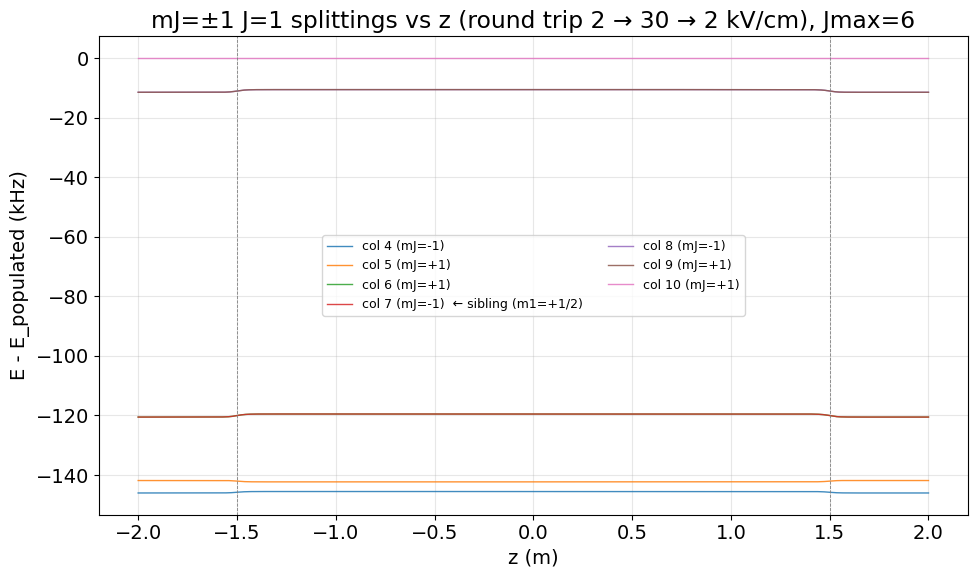

In [8]:
splittings_z_pm1_kHz = (energies_z[:, j1_pm1_idx] - energies_z[:, populated_idx, None]) / (
    2 * np.pi * 1e3
)

fig, ax = plt.subplots(figsize=(10, 6))
for k, col in enumerate(j1_pm1_idx):
    if col == populated_idx:
        continue  # populated is the reference (curve = 0); skip to let y autoscale
    label = f"col {col} (mJ={mJ_per_col[col]:+d})"
    if col == sibling_idx:
        label += "  ← sibling (m1=+1/2)"
    ax.plot(z_grid, splittings_z_pm1_kHz[:, k], lw=1.0, alpha=0.85, label=label)
ax.axvline(-DC_HALF_WIDTH, ls="--", color="gray", lw=0.6)
ax.axvline(+DC_HALF_WIDTH, ls="--", color="gray", lw=0.6)
ax.set_xlabel("z (m)")
ax.set_ylabel("E - E_populated (kHz)")
ax.set_title(
    f"mJ=±1 J=1 splittings vs z (round trip {E_LOW * 1e-3:.0f} → "
    f"{E_HIGH * 1e-3:.0f} → {E_LOW * 1e-3:.0f} kV/cm), Jmax={JMAX}"
)
ax.legend(loc="best", fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Plot 2: 8 mJ=±1 J=1 splittings vs |E_dc| (Stark-map view)

Same data plotted against |E_dc| directly. Because the Stark map depends only on |E| (DC direction is fixed), the up- and down-going legs of the trajectory trace identical curves at the same |E|.

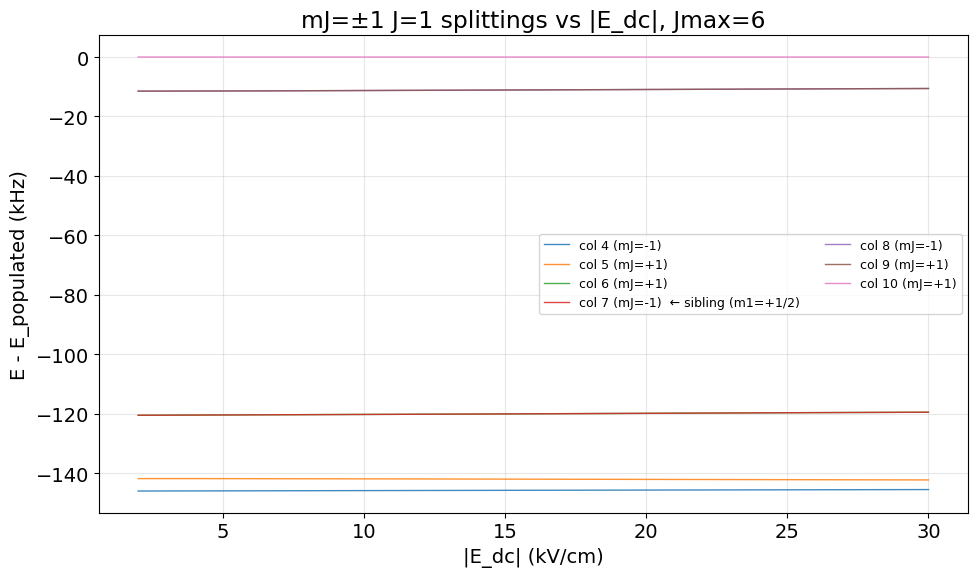

In [9]:
splittings_E_pm1_kHz = (energies_E[:, j1_pm1_idx] - energies_E[:, populated_idx, None]) / (
    2 * np.pi * 1e3
)

fig, ax = plt.subplots(figsize=(10, 6))
for k, col in enumerate(j1_pm1_idx):
    if col == populated_idx:
        continue
    label = f"col {col} (mJ={mJ_per_col[col]:+d})"
    if col == sibling_idx:
        label += "  ← sibling (m1=+1/2)"
    ax.plot(E_grid * 1e-3, splittings_E_pm1_kHz[:, k], lw=1.0, alpha=0.85, label=label)
ax.set_xlabel("|E_dc| (kV/cm)")
ax.set_ylabel("E - E_populated (kHz)")
ax.set_title(f"mJ=±1 J=1 splittings vs |E_dc|, Jmax={JMAX}")
ax.legend(loc="best", fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Focused: m_I1 = +1/2 sibling vs populated

The single splitting `E_sibling − E_populated` (kHz) where the sibling differs from the populated state **only in m1** (Tl nuclear spin projection: +1/2 instead of −1/2). All other quantum numbers — J=1, mJ=−1, m2=−1/2, parity, electronic state — are identical at the bare-target level, and remain shared in the dressed/Hungarian-tracked state because mJ, m1, m2 are all conserved by the static DC Stark Hamiltonian (only J is mixed).

Two plots: vs trajectory `z` (round trip) and vs `|E_dc|`. The splitting is small (~kHz) because it comes from the small Tl-spin–rotation hyperfine coupling, modulated by the Stark-induced J-mixing that changes the rotational expectation value seen by the nuclear spin.

**This is the resonance for the demo's magnetic-RF Ramsey scheme** (`OMEGA_RF = 2π·120 kHz`). The populated→sibling transition is a textbook NMR-style nuclear spin flip driven directly by the nuclear Zeeman component of the RF magnetic field. See `demo_ramsey_rf_coupling.ipynb` for the matrix element `⟨sib|HZx|pop⟩` and the resulting Rabi frequency along the trajectory.

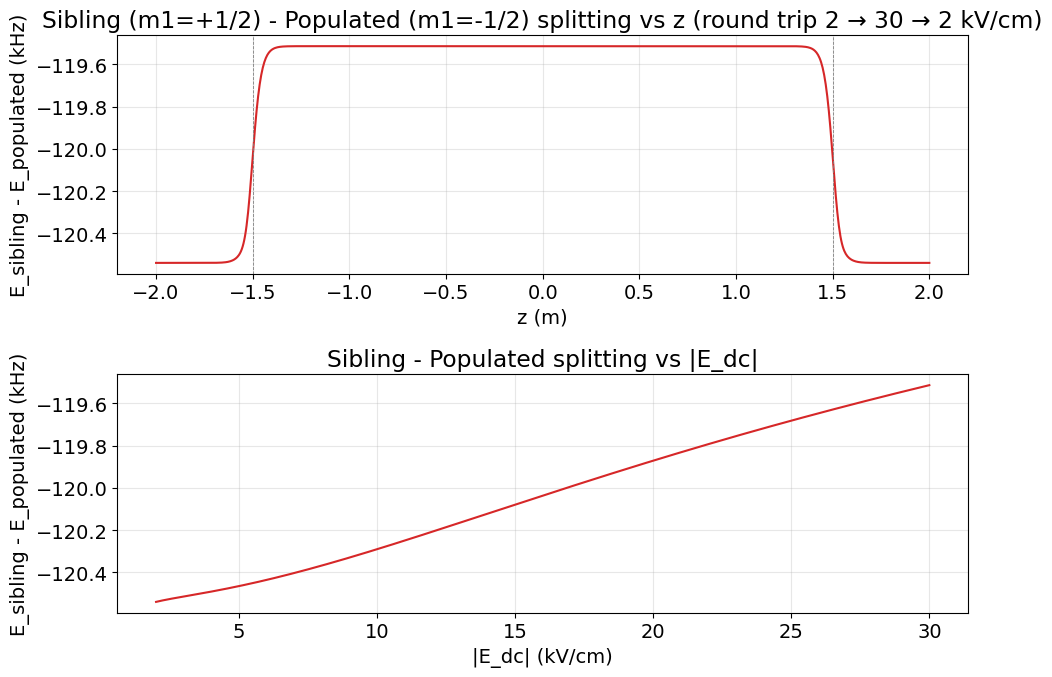

Sibling - populated splitting: -120.540 kHz at 2 kV/cm  →  -119.514 kHz at 30 kV/cm


In [10]:
sib_split_E_kHz = (energies_E[:, sibling_idx] - energies_E[:, populated_idx]) / (2 * np.pi * 1e3)
sib_split_z_kHz = (energies_z[:, sibling_idx] - energies_z[:, populated_idx]) / (2 * np.pi * 1e3)

fig, (ax_z, ax_E) = plt.subplots(2, 1, figsize=(10, 7))

ax_z.plot(z_grid, sib_split_z_kHz, color="C3", lw=1.5)
ax_z.axvline(-DC_HALF_WIDTH, ls="--", color="gray", lw=0.6)
ax_z.axvline(+DC_HALF_WIDTH, ls="--", color="gray", lw=0.6)
ax_z.set_xlabel("z (m)")
ax_z.set_ylabel("E_sibling - E_populated (kHz)")
ax_z.set_title(
    "Sibling (m1=+1/2) - Populated (m1=-1/2) splitting vs z "
    f"(round trip {E_LOW * 1e-3:.0f} → {E_HIGH * 1e-3:.0f} → {E_LOW * 1e-3:.0f} kV/cm)"
)
ax_z.grid(alpha=0.3)

ax_E.plot(E_grid * 1e-3, sib_split_E_kHz, color="C3", lw=1.5)
ax_E.set_xlabel("|E_dc| (kV/cm)")
ax_E.set_ylabel("E_sibling - E_populated (kHz)")
ax_E.set_title("Sibling - Populated splitting vs |E_dc|")
ax_E.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"Sibling - populated splitting: "
    f"{sib_split_E_kHz[0]:+.3f} kHz at 2 kV/cm  →  "
    f"{sib_split_E_kHz[-1]:+.3f} kHz at 30 kV/cm"
)

## 10. Energy

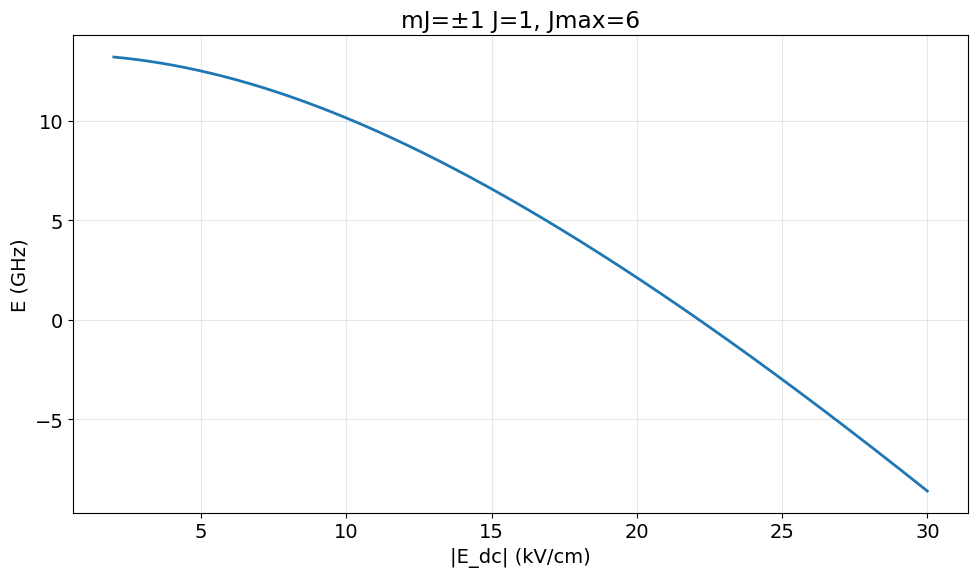

In [11]:
energy = energies_E[:, populated_idx] / (2 * np.pi * 1e9)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(E_grid * 1e-3, energy, lw=2.0)
ax.set_xlabel("|E_dc| (kV/cm)")
ax.set_ylabel("E (GHz)")
ax.set_title(f"mJ=±1 J=1, Jmax={JMAX}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Notes

- The DC E-field direction is fixed `(0, 0, 1)`, so the Stark map at each `z` depends only on `|E_dc(z)|`. This is what lets us compute the Stark map once on a uniform `|E|` grid and reuse it on both legs of the trajectory.
- The B bias of 1e-5 G is far below any spectroscopic feature; it only serves to lift exact zero-field degeneracies so the Hungarian assignment is well-defined at low field.
- **"J=1 ancestor" vs "J=1 character":** the 12 dressed eigenstates identified by `dressed_initial_states` at 2 kV/cm are J=1-dominant at low field (≥96%) but Stark-mix heavily by 30 kV/cm. The 8 mJ=±1 ancestors stay J=1-dominant (~60% J=1, ~35% J=2). The 4 mJ=0 ancestors lose J=1 character (~36% J=0, ~4% J=1, ~45% J=2, ~14% J=3) — they appear at +20 GHz on Plot 1/2 because Hungarian tracks the smooth adiabatic branch, but they are NOT really J=1 in the high-field plateau. See Section 6 for the per-column J-character breakdown.
- mJ, m1, m2 are conserved by the static DC Stark Hamiltonian (E ∥ ẑ, no nuclear-Stark coupling). Only J is mixed. So the populated and sibling states track unique (mJ, m1, m2) labels even at high field — only J becomes "soft".
- Increase `JMAX` to 7 or 8 if you need to verify J-mixing convergence; eigh time scales as O(N^3) where N = (J+1)^2 * 4.